In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import keras
from tensorflow import keras
from keras import layers
from tensorflow import random
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import ops
from tensorflow.keras.backend import clear_session
from tensorflow.keras import mixed_precision
from PIL import Image
import json
import requests
import time
import warnings
from matplotlib.axis import XAxis
import cv2
warnings.filterwarnings('ignore')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
tf.debugging.set_log_device_placement(False)
tf.config.list_logical_devices()

[LogicalDevice(name='/device:CPU:0', device_type='CPU'),
 LogicalDevice(name='/device:GPU:0', device_type='GPU')]

In [22]:
input_shape = (204,146)
input_shape_channels = (204,146,3)

datagen = ImageDataGenerator(
    rescale=1./255,               
    rotation_range=10,                    
    zoom_range=0.1,               
    brightness_range=[0.7, 1.3],       
    fill_mode='nearest'           
)

train_generator = datagen.flow_from_directory(
    'Dataset/',
    target_size=input_shape, 
    color_mode= 'rgb',
    batch_size=16,
    class_mode='categorical',
    seed=42,
    save_format= 'jpg'
)


Found 104030 images belonging to 104030 classes.


In [3]:
@tf.keras.utils.register_keras_serializable(package='Sampling')
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon
        
input_shape = (204, 146, 3)
latent_dim = 100 

inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ZeroPadding2D(((0,0),(0,1)))(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ZeroPadding2D(((0,1),(0,1)))(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ZeroPadding2D(((0,0),(0,1)))(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)

x = layers.Flatten()(x)


z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


decoder_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(13 * 10 * 512, activation='relu')(decoder_input)
x = layers.Reshape((13, 10, 512))(x)

x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(512, (3, 3), activation='relu', padding='same')(x)

x = layers.UpSampling2D((2, 2))(x)
x = layers.Cropping2D(((0,0),(0,1)))(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(256, (3, 3), activation='relu', padding='same')(x)

x = layers.UpSampling2D((2, 2))(x)
x = layers.Cropping2D(((0,1),(0,1)))(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x)

x = layers.UpSampling2D((2, 2))(x)
x = layers.Cropping2D(((0,0),(0,1)))(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)

x = layers.UpSampling2D((2, 2))(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
decoder = keras.Model(decoder_input, decoder_output)
decoder.summary()

outputs = decoder(z)


@tf.keras.utils.register_keras_serializable(package='VAE')
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
    
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data[0])
            reconstruction = self.decoder(z)
            data, _ = data
            #data = tf.reshape(data, (16, 204, 146, 3))
            reconstruction_loss = ops.mean(
                ops.sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
    def get_config(self):
        config = super(VAE, self).get_config()
        config.update({
            'encoder': self.encoder,
            'decoder': self.decoder
        })
        return config

    @classmethod
    def from_config(cls, config):
        encoder = config.pop('encoder')
        decoder = config.pop('decoder')
        return cls(encoder, decoder, **config)

vae = VAE(encoder, decoder)
opt = keras.optimizers.Adam()
vae.compile(optimizer=opt)
vae.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 204, 146,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 204, 146,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 204, 146,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 102, 73,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 102, 73,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 102, 73,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 102, 74,   │          0 │ batch_normalizat… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 51, 37,    │          0 │ zero_padding2d[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 51, 37,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 51, 37,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 52, 38,    │          0 │ batch_normalizat… │
│ (ZeroPadding2D)     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 26, 19,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 26, 19,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26, 19,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 26, 20,    │          0 │ batch_normalizat… │
│ (ZeroPadding2D)     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 13, 10,    │          0 │ zero_padding2d_2… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 13, 10,    │  1,180,160 │ max_pooling2d_3[

 Total params: 14,884,744 (56.78 MB)

 Trainable params: 14,882,760 (56.77 MB)

 Non-trainable params: 1,984 (7.75 KB)

...

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ [(None, 100), (None,   │    14,884,744 │
│                                 │ 100), (None, 100)]     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 204, 146, 3)    │    10,656,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,541,067 (97.43 MB)

 Trainable params: 25,536,139 (97.41 MB)

 Non-trainable params: 4,928 (19.25 KB)

In [ ]:
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

vae.fit(
    train_generator,
    epochs=100,
    batch_size = 16
)

In [31]:
# tf.keras.utils.get_custom_objects()['VAE'] = VAE
vae.save_weights("./Modelos/TestRE50epoch.weights.h5",overwrite=False)

[WARNING] ./Modelos/TestRE50epochNofunciona.weights.h5 already exists - overwrite? [y/n] n


In [4]:
#codes = vae.encoder(tf.zeros((1, 204, 146, 3)))
#img = vae.decoder(codes[2])

vae.load_weights("./Modelos/ModeloGPU.weights.h5",skip_mismatch=False)

tf.Tensor(
[[-0.5212657   0.5983135  -1.2973756  -2.2313056  -0.49395707 -0.08727713
   0.7181942  -0.29439792 -1.770391    0.37603438 -1.3569896  -1.9598091
  -0.9491999   0.23102522  1.7424206  -0.41371197 -0.45957488 -0.75537044
   1.2616992   0.30930418  0.93549913 -0.8249787  -0.3366585  -0.76631016
  -0.40046388  1.1698815  -0.24684548  0.86261845  0.12401368  1.4512992
  -0.1394097  -0.414523   -0.73824424 -0.9114459   1.1950116   0.7622084
  -0.00501322  0.08729501 -0.6510587  -0.49711853 -0.21017359  0.12196651
   1.1347685   0.00260413 -1.9225699  -0.02589221 -0.4648602   0.06046505
   2.3259587  -0.48995525  0.08551893 -0.92581314  0.6955211   0.559476
   0.7181009   0.55801535 -0.14068109  1.1463215  -0.02887417 -0.31827542
  -0.52111477 -1.2569362   0.4583544   0.6145803  -0.4120831  -1.598787
   0.12008667  0.5692855  -1.1879165  -0.01735057  0.9192388   1.4691827
  -0.48162803 -0.39921033 -0.20889226 -0.09627451  2.2059765  -0.2519623
   0.30258167 -0.4232243  -1.377795 

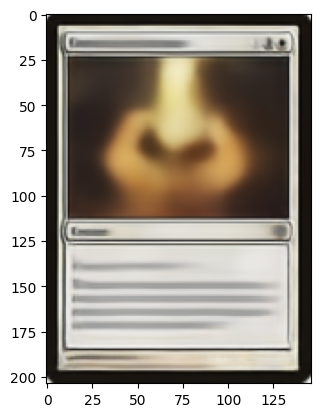

In [6]:
def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    image = image.resize((146, 204))  
    image = np.array(image)
    image = image.astype('float32') / 255.0  
    image = np.expand_dims(image, axis=0) 
    return image

path = "./DatasetTFGIngles/a74d1bf3-4630-4be0-af5f-590789d27a0c/a74d1bf3-4630-4be0-af5f-590789d27a0c.jpg"

test = load_and_preprocess_image(path)
codes = vae.encoder(test)
img = vae.decoder(codes[2])
img = tf.reshape(img,(204,146,3))
print(codes[2])
plt.imshow(img)

In [34]:
def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize((146, 204))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image

inicio = time.time()
carpeta = './TestVectoresActualizados'
v = []
d = []

i = 0
total = len(os.listdir(carpeta))
for nombre_carpeta in os.listdir(carpeta):
    for nombre_archivo in os.listdir(carpeta + "/" + nombre_carpeta):
        if nombre_archivo.endswith('.jpg'):
            image_path = carpeta + "/" + nombre_carpeta + "/" + nombre_archivo
            test_image = load_and_preprocess_image(image_path)
            i += 1
            per = (i/total)*100
            bar = '#'*int(per/10)
            print(f"\r[{bar.ljust(10)}]% {per}{image_path}#{test_image.shape}",end = '                    ', flush = True)
            codes = vae.encoder(test_image)
            v.append(codes[0])
            d.append(os.path.splitext(nombre_archivo)[0])

v = np.array(v)
d = np.array(d)
np.save('vectores.npy', v)  
np.save('ids.npy', d)
fin = time.time()
print(f"Tiempo ejecucion(comparaciones): {fin - inicio}")

Tiempo ejecucion(comparaciones): 3658.4390664100647825-9996-4ae5-90c8-cb976ccf4ae0/ffff0825-9996-4ae5-90c8-cb976ccf4ae0.jpg#(1, 204, 146, 3)                                               


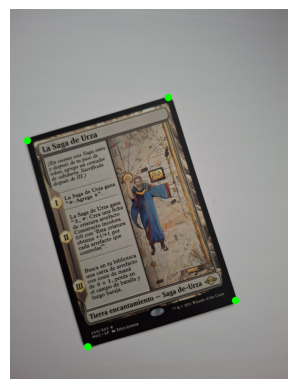

Tiempo Euclídeana: 0.020282745361328125
Euclídeana: Urza's Saga 9df37469-6e2d-4783-aad3-c897ecbc967d
Tiempo Coseno: 0.019315481185913086
Coseno: Urza's Saga 9df37469-6e2d-4783-aad3-c897ecbc967d
Tiempo Pearson: 0.03837251663208008
Pearson: Urza's Saga 9df37469-6e2d-4783-aad3-c897ecbc967d


In [9]:
def encuadrar(path, name):
    imgBGR = cv2.imread(path, cv2.IMREAD_COLOR)
    imgRGB = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2RGB)
    
    gray = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (7, 7), 0)
    edges = cv2.Canny(gray, 50, 150)
    thresh = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21,
        5
    )
    thresh = cv2.bitwise_not(thresh)
    thresh = cv2.bitwise_or(thresh, edges)
    
    
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    
    conts, _ = cv2.findContours(
        thresh,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )
    
    candidates = []
    
    for c in conts:
        c = cv2.convexHull(c)
        area = cv2.contourArea(c)
        h, w = gray.shape
        if area < (h * w) * 0.05:
            continue
        epsilon = 0.02 * cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, epsilon, True)
    
        if len(approx) == 4:
            candidates.append((area, approx))
    
    if not candidates:
        #raise Exception("No se encontró ningún contorno de 4 lados")
        return
        
    card = max(candidates, key=lambda x: x[0])[1]
    
    pts = card.reshape(4, 2).astype("float32")
    
    rect = np.zeros((4, 2), dtype="float32")
    
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    
    width, height = 146, 204
    
    dst = np.float32([
        [0, 0],
        [width, 0],
        [width, height],
        [0, height]
    ])
    
    M = cv2.getPerspectiveTransform(rect, dst)
    final = cv2.warpPerspective(imgBGR, M, (width, height))
    
    debug = imgRGB.copy()
    for p in rect:
        cv2.circle(debug, tuple(p.astype(int)), 40, (5, 255, 0), -1)
    #cv2.imwrite("./figures/Urza_Esquinas.jpg",debug)
    #cv2.imwrite("./figures/Urza_Encuadrada.jpg",final)
    plt.imshow(debug)
    plt.axis("off")
    plt.show()

    folder = "./imagenesEncuadradas/"

    if not os.path.exists(folder):
        os.makedirs(folder)

    cv2.imwrite(folder + name + ".jpg",final)

def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize((146, 204))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image

def distanciaEuclidiana(tensor1,tensor2):
    return tf.norm(tensor1-tensor2)

def similitudCosenoMedia(tensor1,tensor2):
    return tf.reduce_mean(-tf.keras.losses.cosine_similarity(tensor1,tensor2))

def correlacionPearson(tensor1,tensor2):
    mean1 = tf.reduce_mean(tensor1)
    mean2 = tf.reduce_mean(tensor2)
    std1 = tf.math.reduce_std(tensor1)
    std2 = tf.math.reduce_std(tensor2)
    correlacion_pearson = tf.reduce_mean((tensor1 - mean1) * (tensor2 - mean2)) / (std1 * std2)
    return correlacion_pearson.numpy()

vectores = np.load('vectores.npy')
ids = np.load('ids.npy')
names = np.load('nombres.npy')

#print(vectores.shape)
vectores = np.squeeze(vectores, axis=1)
#print(vectores.shape)

encuadrar("./TestsImages/Urza's Saga.jpg", "Urza's Saga")
image_path = "./imagenesEncuadradas/Urza's Saga.jpg"

code = vae.encoder(load_and_preprocess_image(image_path))[0]

inicio = time.time()

DE = tf.norm(vectores - code, axis=1)
DE = tf.argmin(DE)
fin = time.time()

print(f"Tiempo Euclídeana: {fin - inicio}")
print("Euclídeana:", names[DE], ids[DE])

inicio = time.time()

SC = tf.keras.losses.cosine_similarity(code, vectores)
SC = tf.argmin(SC)
fin = time.time()

print(f"Tiempo Coseno: {fin - inicio}")
print("Coseno:", names[SC], ids[SC])


inicio = time.time()

mean1 = tf.reduce_mean(vectores,axis=1,keepdims=True)
mean2 = tf.reduce_mean(code)
std1 = tf.math.reduce_std(vectores,axis=1,keepdims=True)
std2 = tf.math.reduce_std(code)

CPear = tf.reduce_mean(((vectores - mean1) / std1 ) * ((code - mean2) / std2), axis=1)
CPear = tf.argmax(CPear)


fin = time.time()

print(f"Tiempo Pearson: {fin - inicio}")
print("Pearson:", names[CPear], ids[CPear])

In [10]:
def encuadrar(path, name):
    imgBGR = cv2.imread(path, cv2.IMREAD_COLOR)
    imgRGB = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2RGB)
    
    gray = cv2.cvtColor(imgBGR, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (7, 7), 0)
    edges = cv2.Canny(gray, 50, 150)
    thresh = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21,
        5
    )
    thresh = cv2.bitwise_not(thresh)
    thresh = cv2.bitwise_or(thresh, edges)
    
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    
    conts, _ = cv2.findContours(
        thresh,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )
    
    candidates = []
    
    for c in conts:
        c = cv2.convexHull(c)
        area = cv2.contourArea(c)
        h, w = gray.shape
        if area < (h * w) * 0.05:
            continue
        epsilon = 0.02 * cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, epsilon, True)
    
        if len(approx) == 4:
            candidates.append((area, approx))
    
    if not candidates:
        #raise Exception("No se encontró ningún contorno de 4 lados")
        return
        
    card = max(candidates, key=lambda x: x[0])[1]
    
    pts = card.reshape(4, 2).astype("float32")
    
    rect = np.zeros((4, 2), dtype="float32")
    
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    
    width, height = 146, 204
    
    dst = np.float32([
        [0, 0],
        [width, 0],
        [width, height],
        [0, height]
    ])
    
    M = cv2.getPerspectiveTransform(rect, dst)
    final = cv2.warpPerspective(imgBGR, M, (width, height))
    
    debug = imgRGB.copy()
    for p in rect:
        cv2.circle(debug, tuple(p.astype(int)), 40, (5, 255, 0), -1)
    
    #plt.imshow(debug)
    #plt.axis("off")
    #plt.show()
    folder = "./TestsImageEncuadradas/"

    if not os.path.exists(folder):
        os.makedirs(folder)

    cv2.imwrite(folder + name + ".jpg",final)


def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize((146, 204))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image

def distanciaEuclidiana(tensor1,tensor2):
    return tf.norm(tensor1-tensor2)

def similitudCosenoMedia(tensor1,tensor2):
    return tf.reduce_mean(-tf.keras.losses.cosine_similarity(tensor1,tensor2))

def correlacionPearson(tensor1,tensor2):
    mean1 = tf.reduce_mean(tensor1)
    mean2 = tf.reduce_mean(tensor2)
    std1 = tf.math.reduce_std(tensor1)
    std2 = tf.math.reduce_std(tensor2)
    correlacion_pearson = tf.reduce_mean((tensor1 - mean1) * (tensor2 - mean2)) / (std1 * std2)
    return correlacion_pearson.numpy()
inicio = time.time()
vectores = np.load('vectores.npy')
ids = np.load('ids.npy')
names = np.load('nombres.npy')

folder = "./TestImagesFinal/"
image_files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")])
images = [np.array(Image.open(os.path.join(folder, f))) for f in image_files]
image_names = [os.path.splitext(f)[0] for f in image_files]

#print(image_names[0])
#plt.subplot(111), plt.title("Carta:"), plt.axis("off")
#plt.imshow(images[0])
print("Número de imágenes:", len(images))

for i in range(len(images)):
    encuadrar(folder + image_names[i] + ".jpg", image_names[i])

folder = "./TestsImageEncuadradas/"
image_files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".jpg")])
images = [np.array(Image.open(os.path.join(folder, f))) for f in image_files]
image_names = [os.path.splitext(f)[0] for f in image_files]

codes = [vae.encoder(load_and_preprocess_image(folder + image_names[0] + ".jpg"))] * len(images)
for i in range(len(images)):
    codes[i] = vae.encoder(load_and_preprocess_image(folder + image_names[i] + ".jpg"))

maxCorrPear = [0] * len(images)
DE = [2**31 - 1] * len(images)
maxSC = [2**31 - 1] * len(images)

idCorrPear = [ids[0]] * len(images)
idDP = [ids[0]] * len(images)
idSC = [ids[0]] * len(images)

nameCorrPear = [names[0]] * len(images)
nameDP = [names[0]] * len(images)
nameSC = [names[0]] * len(images)

vectores = np.squeeze(vectores, axis=1)
total = len(codes)
i = 0

CPear = [0] * len(images)
DE = [2**31 - 1] * len(images)
SC = [2**31 - 1] * len(images)

for code in codes:
    per = (i/total)*100
    bar = '#'*int(per/10)
    print(f"\r[{bar.ljust(10)}] {per}%",end = '                    ', flush = True)

    code = code[0]
    
    DE[i] = tf.norm(vectores - code, axis=1)
    DE[i] = tf.argmin(DE[i])

    SC[i] = tf.keras.losses.cosine_similarity(code, vectores)
    SC[i] = tf.argmin(SC[i])

    mean1 = tf.reduce_mean(vectores,axis=1,keepdims=True)
    mean2 = tf.reduce_mean(code)
    std1 = tf.math.reduce_std(vectores,axis=1,keepdims=True)
    std2 = tf.math.reduce_std(code)

    CPear[i] = tf.reduce_mean(((vectores - mean1) / std1 ) * ((code - mean2) / std2), axis=1)

    CPear[i] = tf.argmax(CPear[i])
    i = i + 1
  
fin = time.time() 
print(f"Tiempo ejecucion(comparaciones): {fin - inicio}")

for i in range(len(image_names)):
    if image_names[i] == "Sorin of House Markov  Sorin, Ravenous Neonate 2" or image_names[i] == "Sorin of House Markov  Sorin, Ravenous Neonate":
        image_names[i] = "Sorin of House Markov // Sorin, Ravenous Neonate"

CorrPearCorrect = 0
DPCorrect = 0
SCCorrect = 0

nameCorrPear = [names[0]] * len(images)
nameDP = [names[0]] * len(images)
nameSC = [names[0]] * len(images)

for i in range(len(images)):
    nameCorrPear[i] = names[CPear[i]]
    nameDP[i] = names[DE[i]]
    nameSC[i] = names[SC[i]]

for i in range(len(images)):
    if nameCorrPear[i] == image_names[i]:
        CorrPearCorrect += 1
    if nameDP[i] == image_names[i]:
        DPCorrect += 1
    if  nameSC[i] == image_names[i]:
        SCCorrect += 1

print(image_names)

print("Correlacion de pearson: ")
percentage = (CorrPearCorrect/len(images))*100
print(f"{CorrPearCorrect} of {len(images)}")
print(f"{percentage}%")
print(nameCorrPear)

print("Distancia Euclideana: ")
percentage = (DPCorrect/len(images))*100
print(f"{DPCorrect} of {len(images)}")
print(f"{percentage}%")
print(nameDP)

print("Similitud del coseno: ")
percentage = (SCCorrect/len(images))*100
print(f"{SCCorrect} of {len(images)}")
print(f"{percentage}%")
print(nameSC)

Número de imágenes: 130
Tiempo ejecucion(comparaciones): 69.7250747680664   
['Acidic Slime', 'Adaptive Training Post', 'Aligned Heart', 'Archmage Emeritus', 'Ashenmoor Liege', 'Azure Beastbinder', 'Barrenton Medic', 'Bearer of Glory', 'Bellowing Crier', 'Bitter Triumph', 'Bloodscale Prowler', 'Bogardan Hellkite', 'Boulderborn Dragon', 'Brave-Kin Duo', 'Brighthearth Banneret', 'Cache Grab', 'Chittering Witch', 'Conduct Electricity', 'Copy', 'Corrupted Crossroads', 'Crackling Cyclops', 'Darksteel Monolith', 'Dazzling Denial', "Descendants' Path", 'Diresight', 'Duergar Hedge-Mage', 'Echoes of Eternity', 'Elsha, Threefold Master', 'Emberheart Challenger', 'Emeria Angel', 'Emrakul, the World Anew', 'Everflowing Chalice', 'Evolving Wilds', 'Faceless Butcher', 'Faithful Watchdog', 'Feed the Cycle', 'Fellwar Stone', 'Fire-Belly Changeling', 'Forest', 'Forsaken Monument', 'Gelectrode', 'Gev, Scaled Scorch', 'Glidedive Duo', "Gossip's Talent", 'Grasslands', 'Heartfire Hero', 'Hearthfire Hobgobl